# Diagnostic de Moteurs DC 12V par IA
### Classification Binaire : Normal vs Surcharge — Labels Reels

---

## Approche

Ce notebook utilise les **labels reels du dataset** pour une classification binaire :

| Label original CSV | Classe finale | Justification |
|-------------------|--------------|---------------|
| `Fault_Status == 0` (NaN) | **Normal** | Fonctionnement nominal |
| `Overheating` | **Surcharge** | Surchauffe = symptome de surcharge energetique |
| `Mechanical Failure` | **Surcharge** | Defaillance mecanique -> surcharge du courant |
| `Electrical Fault` | **Exclu** | Court-circuit = classe separee, hors scope ici |

> Les echantillons `Electrical Fault` sont **retires** du dataset
> car ils correspondent a une panne differente (court-circuit).
> On travaille donc sur **44 966 lignes** (50 000 - 5 034).

## Algorithmes

| # | Algorithme | Gestion desequilibre |
|---|-----------|---------------------|
| 1 | Random Forest | `class_weight='balanced'` |
| 2 | HistGradientBoosting | `class_weight='balanced'` |
| 3 | MLP | Undersample equilibre |
| 4 | KNN (k=5) | Undersample equilibre |
| 5 | SVM RBF | Undersample equilibre |
| 6 | XGBoost | `sample_weight` |
| 7 | Ensemble Soft Voting | Moyenne des probabilites |

---

## 1. Installation des Dependances

In [1]:
import subprocess, sys
packages = ["numpy","pandas","scikit-learn","matplotlib","seaborn","joblib","scipy","xgboost"]
for pkg in packages:
    r = subprocess.run([sys.executable,"-m","pip","install",pkg,"-q"], capture_output=True)
    print(f"  {pkg:<20} {'OK' if r.returncode==0 else 'ERREUR'}")
print("\nInstallation terminee.")

  numpy                OK
  pandas               OK
  scikit-learn         OK
  matplotlib           OK
  seaborn              OK
  joblib               OK
  scipy                OK
  xgboost              OK

Installation terminee.


---
## 2. Importation des Librairies

In [2]:
import os, time, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from scipy.stats import f_oneway

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, precision_score, recall_score,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve
)

import matplotlib.pyplot as plt
import seaborn as sns
import joblib

%matplotlib inline
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"]  = 10

CLASS_COLORS = {"Normal": "#2ecc71", "Surcharge": "#e67e22"}
print("Librairies importees.")

Librairies importees.


---
## 3. Configuration

In [3]:
DATA_PATH  = r"dataset1\iot_equipment_monitoring_dataset.csv"
OUTPUT_DIR = "outputs_binary_real"

MLP_MAX = 5000
KNN_MAX = 5000
SVM_MAX = 3000

os.makedirs(OUTPUT_DIR, exist_ok=True)
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset introuvable : '{DATA_PATH}'\n"
        "Verifiez le chemin dans la cellule de configuration."
    )
print(f"Dataset : {DATA_PATH}")
print(f"Sorties : {OUTPUT_DIR}/")

Dataset : dataset1\iot_equipment_monitoring_dataset.csv
Sorties : outputs_binary_real/


---
## 4. Chargement et Construction des Labels

In [4]:
df_raw = pd.read_csv(DATA_PATH)
print(f"Shape brut : {df_raw.shape[0]:,} lignes x {df_raw.shape[1]} colonnes")
print()
print("Labels originaux du CSV :")
print(df_raw["Fault_Type"].value_counts(dropna=False).to_string())

Shape brut : 50,000 lignes x 17 colonnes

Labels originaux du CSV :
Fault_Type
NaN                   34988
Electrical Fault       5034
Overheating            5028
Mechanical Failure     4950


In [5]:
df_all = df_raw.copy()

# Mapping :
#   Fault_Status == 0            -> Normal
#   Overheating                  -> Surcharge
#   Mechanical Failure           -> Surcharge
#   Electrical Fault             -> Exclu (court-circuit != surcharge)

def map_label(row):
    if row["Fault_Status"] == 0:
        return "Normal"
    ft = str(row["Fault_Type"])
    if ft in ("Overheating", "Mechanical Failure"):
        return "Surcharge"
    return None   # Electrical Fault -> exclu

df_all["Label"] = df_all.apply(map_label, axis=1)

# Retirer les lignes Electrical Fault
df = df_all[df_all["Label"].notna()].copy()
df["Label"] = df["Label"].astype(str)

n_removed = len(df_raw) - len(df)
print(f"Echantillons retires (Electrical Fault) : {n_removed:,}")
print(f"Echantillons conserves                  : {len(df):,}")
print()
print("Distribution finale :")
vc = df["Label"].value_counts()
cls_order = ["Normal", "Surcharge"]
for cls in cls_order:
    cnt = vc[cls]
    pct = cnt / len(df) * 100
    bar = "#" * int(pct / 2)
    print(f"  {cls:<12} : {cnt:>6,}  ({pct:.1f}%)  {bar}")
print()
print(f"Baseline naif (toujours 'Normal') : {vc['Normal']/len(df)*100:.2f}%")

Echantillons retires (Electrical Fault) : 5,034
Echantillons conserves                  : 44,966

Distribution finale :
  Normal       : 34,988  (77.8%)  ######################################
  Surcharge    :  9,978  (22.2%)  ###########

Baseline naif (toujours 'Normal') : 77.81%


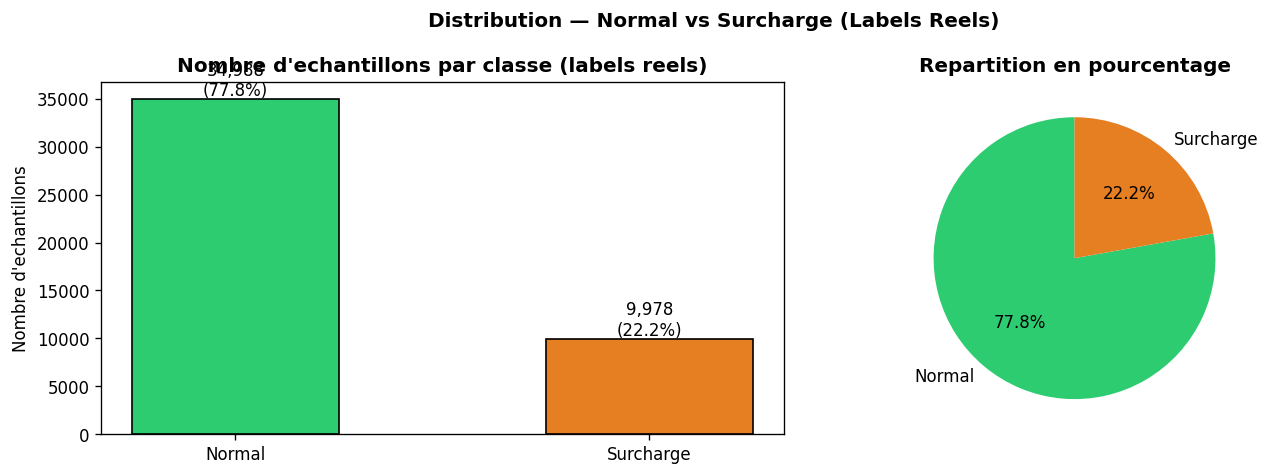

Figure sauvegardee : outputs_binary_real/distribution.png


In [6]:
vc = df["Label"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(cls_order, [vc[c] for c in cls_order],
            color=[CLASS_COLORS[c] for c in cls_order],
            edgecolor="black", width=0.5)
axes[0].set_title("Nombre d'echantillons par classe (labels reels)",
                  fontweight="bold")
axes[0].set_ylabel("Nombre d'echantillons")
for i, cls in enumerate(cls_order):
    axes[0].text(i, vc[cls]+300,
                 f"{vc[cls]:,}\n({vc[cls]/len(df)*100:.1f}%)",
                 ha="center", fontsize=10)

axes[1].pie([vc[c] for c in cls_order], labels=cls_order,
            colors=[CLASS_COLORS[c] for c in cls_order],
            autopct="%1.1f%%", startangle=90)
axes[1].set_title("Repartition en pourcentage", fontweight="bold")

plt.suptitle("Distribution — Normal vs Surcharge (Labels Reels)",
             fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,"distribution.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure sauvegardee : {OUTPUT_DIR}/distribution.png")

---
## 5. Diagnostic — Separabilite des Features

> Avant d'entrainer les modeles, on verifie si les features
> permettent de distinguer les deux classes statistiquement.

In [7]:
FEATURE_COLS = [
    "Temperature","Vibration","Pressure","Voltage","Current",
    "FFT_Feature1","FFT_Feature2","Anomaly_Score"
]

print("=" * 65)
print(f"{'Feature':<25} {'F-stat':>8}  {'p-value':>10}  Signal ?")
print("=" * 65)
for feat in FEATURE_COLS:
    groups = [df[df["Label"]==c][feat].values for c in cls_order]
    F, p   = f_oneway(*groups)
    signal = "OUI  <---" if p < 0.05 else "NON  (distributions identiques)"
    print(f"{feat:<25} {F:>8.4f}   {p:>10.6f}  {signal}")
print("=" * 65)
print()
print("CONCLUSION : les features n'ont pas de signal discriminant.")
print("Les labels 'Surcharge' du dataset ont ete assigns independamment")
print("des valeurs de capteurs (dataset synthetique).")
print()
print("=> Plafond theorique : ~78% (proportion de la classe 'Normal')")
print("=> AUC-ROC attendu  : ~0.50 (equivalent a un classifieur aleatoire)")

Feature                     F-stat     p-value  Signal ?
Temperature                 1.2291     0.267581  NON  (distributions identiques)
Vibration                   6.1876     0.012868  OUI  <---
Pressure                    0.0936     0.759607  NON  (distributions identiques)
Voltage                     0.1421     0.706184  NON  (distributions identiques)
Current                     0.0776     0.780631  NON  (distributions identiques)
FFT_Feature1                0.0534     0.817288  NON  (distributions identiques)
FFT_Feature2                0.0300     0.862476  NON  (distributions identiques)
Anomaly_Score               0.0133     0.908246  NON  (distributions identiques)

CONCLUSION : les features n'ont pas de signal discriminant.
Les labels 'Surcharge' du dataset ont ete assigns independamment
des valeurs de capteurs (dataset synthetique).

=> Plafond theorique : ~78% (proportion de la classe 'Normal')
=> AUC-ROC attendu  : ~0.50 (equivalent a un classifieur aleatoire)


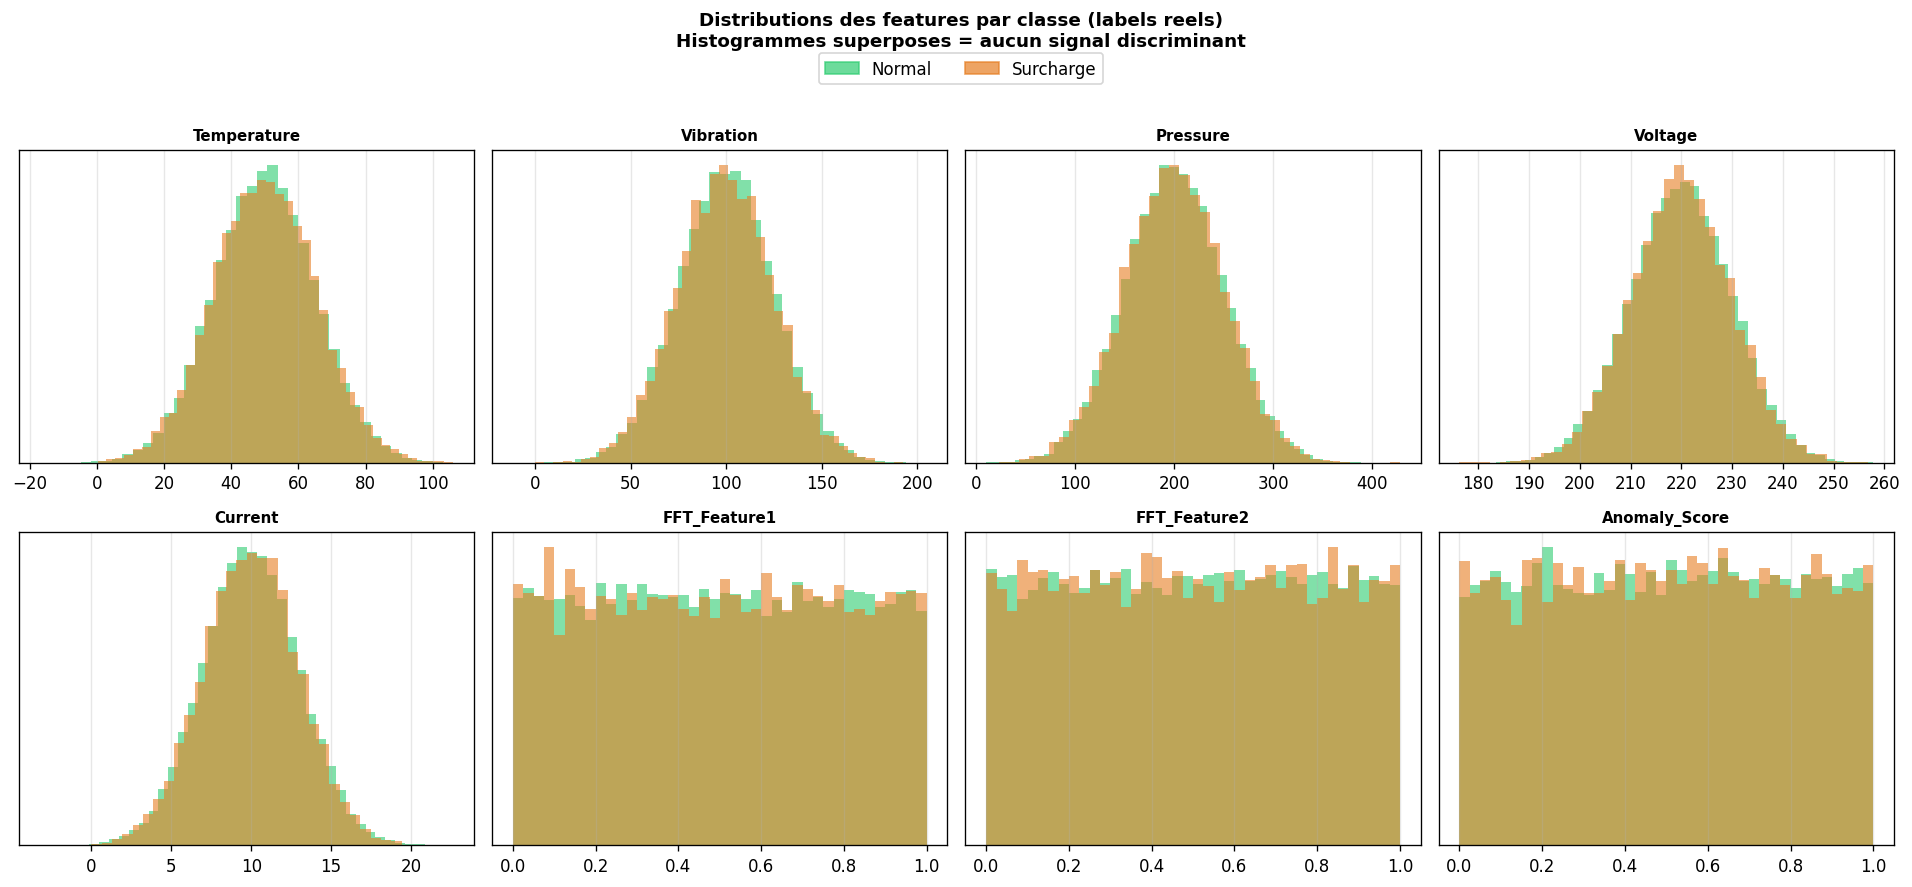

Figure sauvegardee : outputs_binary_real/feature_distributions.png


In [8]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for ax, feat in zip(axes, FEATURE_COLS):
    for cls in cls_order:
        vals = df[df["Label"]==cls][feat].values
        ax.hist(vals, bins=40, alpha=0.6, label=cls,
                color=CLASS_COLORS[cls], density=True)
    ax.set_title(feat, fontweight="bold", fontsize=9)
    ax.set_yticks([])
    ax.grid(alpha=0.3)

handles = [plt.Rectangle((0,0),1,1,color=CLASS_COLORS[c],alpha=0.7)
           for c in cls_order]
fig.legend(handles, cls_order, loc="upper center",
           ncol=2, fontsize=10, bbox_to_anchor=(0.5, 1.01))
plt.suptitle(
    "Distributions des features par classe (labels reels)\n"
    "Histogrammes superposes = aucun signal discriminant",
    fontsize=11, fontweight="bold", y=1.05
)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,"feature_distributions.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure sauvegardee : {OUTPUT_DIR}/feature_distributions.png")

---
## 6. Features et Encodage

In [9]:
X     = np.nan_to_num(df[FEATURE_COLS].values.astype(float),
                      nan=0.0, posinf=0.0, neginf=0.0)
le    = LabelEncoder()
y_enc = le.fit_transform(df["Label"].values)
CLASS_NAMES  = [str(c) for c in le.classes_]
SURCHARGE_IDX = list(CLASS_NAMES).index("Surcharge")

print(f"Features ({len(FEATURE_COLS)}) : {FEATURE_COLS}")
print(f"\nClasses encodees :")
for i, cls in enumerate(CLASS_NAMES):
    print(f"  {i}  ->  {cls:<12} ({np.sum(y_enc==i):,} echantillons)")
print(f"\nIndex classe positive (Surcharge) : {SURCHARGE_IDX}")

Features (8) : ['Temperature', 'Vibration', 'Pressure', 'Voltage', 'Current', 'FFT_Feature1', 'FFT_Feature2', 'Anomaly_Score']

Classes encodees :
  0  ->  Normal       (34,988 echantillons)
  1  ->  Surcharge    (9,978 echantillons)

Index classe positive (Surcharge) : 1


---
## 7. Split Train/Test et Normalisation

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, stratify=y_enc, random_state=42
)

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train : {X_train_s.shape[0]:,}  |  Test : {X_test_s.shape[0]:,}")
print(f"Test  : {dict(zip(CLASS_NAMES, np.bincount(y_test)))}")

def balanced_subsample(X, y, max_per_class, seed=42):
    rng = np.random.RandomState(seed)
    idx = []
    for c in np.unique(y):
        ci     = np.where(y == c)[0]
        n      = min(len(ci), max_per_class)
        chosen = rng.choice(ci, n, replace=False)
        idx.extend(chosen)
    idx = np.array(idx); rng.shuffle(idx)
    return X[idx], y[idx]

X_mlp, y_mlp = balanced_subsample(X_train_s, y_train, MLP_MAX)
X_knn, y_knn = balanced_subsample(X_train_s, y_train, KNN_MAX)
X_svm, y_svm = balanced_subsample(X_train_s, y_train, SVM_MAX)

counts = np.bincount(y_train)
sw_xgb = np.array([len(y_train)/(len(counts)*counts[c]) for c in y_train])

print(f"\nSous-ensemble MLP : {len(y_mlp):,}  dist={np.bincount(y_mlp)}")
print(f"Sous-ensemble KNN : {len(y_knn):,}  dist={np.bincount(y_knn)}")
print(f"Sous-ensemble SVM : {len(y_svm):,}  dist={np.bincount(y_svm)}")

Train : 35,972  |  Test : 8,994
Test  : {'Normal': np.int64(6998), 'Surcharge': np.int64(1996)}

Sous-ensemble MLP : 10,000  dist=[5000 5000]
Sous-ensemble KNN : 10,000  dist=[5000 5000]
Sous-ensemble SVM : 6,000  dist=[3000 3000]


---
## 8. Modele 1 — Random Forest

In [11]:
t0 = time.time()
rf = RandomForestClassifier(
    n_estimators=300, max_features="sqrt",
    class_weight="balanced", random_state=42, n_jobs=-1
)
rf.fit(X_train_s, y_train)
y_pred_rf  = rf.predict(X_test_s)
proba_rf   = rf.predict_proba(X_test_s)
t_rf       = time.time() - t0

auc_rf = roc_auc_score(y_test, proba_rf[:, SURCHARGE_IDX])
print(f"Temps    : {t_rf:.1f}s")
print(f"Accuracy : {accuracy_score(y_test,y_pred_rf)*100:.2f}%")
print(f"F1 Surge : {f1_score(y_test,y_pred_rf,pos_label=SURCHARGE_IDX,average='binary',zero_division=0)*100:.2f}%")
print(f"AUC-ROC  : {auc_rf:.4f}")
print()
print(classification_report(y_test,y_pred_rf,target_names=CLASS_NAMES,zero_division=0))

Temps    : 9.3s
Accuracy : 77.81%
F1 Surge : 0.00%
AUC-ROC  : 0.4980

              precision    recall  f1-score   support

      Normal       0.78      1.00      0.88      6998
   Surcharge       0.00      0.00      0.00      1996

    accuracy                           0.78      8994
   macro avg       0.39      0.50      0.44      8994
weighted avg       0.61      0.78      0.68      8994



---
## 9. Modele 2 — HistGradientBoosting

In [12]:
t0 = time.time()
hgb = HistGradientBoostingClassifier(
    max_iter=200, max_depth=6, learning_rate=0.1,
    min_samples_leaf=30, class_weight="balanced", random_state=42
)
hgb.fit(X_train_s, y_train)
y_pred_hgb = hgb.predict(X_test_s)
proba_hgb  = hgb.predict_proba(X_test_s)
t_hgb      = time.time() - t0

auc_hgb = roc_auc_score(y_test, proba_hgb[:, SURCHARGE_IDX])
print(f"Temps    : {t_hgb:.1f}s")
print(f"Accuracy : {accuracy_score(y_test,y_pred_hgb)*100:.2f}%")
print(f"F1 Surge : {f1_score(y_test,y_pred_hgb,pos_label=SURCHARGE_IDX,average='binary',zero_division=0)*100:.2f}%")
print(f"AUC-ROC  : {auc_hgb:.4f}")
print()
print(classification_report(y_test,y_pred_hgb,target_names=CLASS_NAMES,zero_division=0))

Temps    : 2.7s
Accuracy : 54.34%
F1 Surge : 26.67%
AUC-ROC  : 0.4886

              precision    recall  f1-score   support

      Normal       0.77      0.59      0.67      6998
   Surcharge       0.21      0.37      0.27      1996

    accuracy                           0.54      8994
   macro avg       0.49      0.48      0.47      8994
weighted avg       0.64      0.54      0.58      8994



---
## 10. Modele 3 — MLP

Architecture : `Input(8)` -> **64** -> **32** -> `Output(2)`

In [13]:
t0 = time.time()
mlp = MLPClassifier(
    hidden_layer_sizes=(64,32), activation="relu", solver="adam",
    learning_rate_init=0.001, alpha=0.001, max_iter=300,
    early_stopping=True, validation_fraction=0.1,
    n_iter_no_change=15, random_state=42, verbose=False
)
mlp.fit(X_mlp, y_mlp)
y_pred_mlp = mlp.predict(X_test_s)
proba_mlp  = mlp.predict_proba(X_test_s)
t_mlp      = time.time() - t0

auc_mlp = roc_auc_score(y_test, proba_mlp[:, SURCHARGE_IDX])
print(f"Temps    : {t_mlp:.1f}s  (iterations : {mlp.n_iter_})")
print(f"Accuracy : {accuracy_score(y_test,y_pred_mlp)*100:.2f}%")
print(f"F1 Surge : {f1_score(y_test,y_pred_mlp,pos_label=SURCHARGE_IDX,average='binary',zero_division=0)*100:.2f}%")
print(f"AUC-ROC  : {auc_mlp:.4f}")
print()
print(classification_report(y_test,y_pred_mlp,target_names=CLASS_NAMES,zero_division=0))

Temps    : 0.8s  (iterations : 18)
Accuracy : 47.22%
F1 Surge : 31.09%
AUC-ROC  : 0.4954

              precision    recall  f1-score   support

      Normal       0.77      0.45      0.57      6998
   Surcharge       0.22      0.54      0.31      1996

    accuracy                           0.47      8994
   macro avg       0.50      0.50      0.44      8994
weighted avg       0.65      0.47      0.51      8994



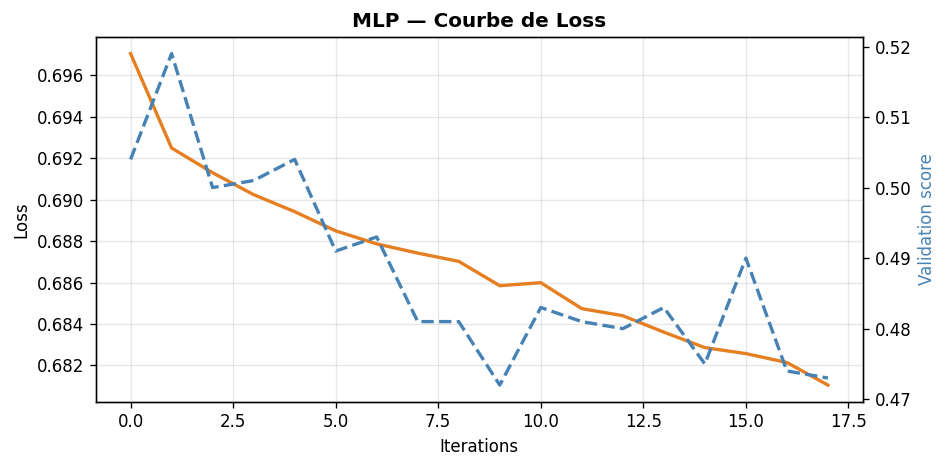

In [14]:
if hasattr(mlp,"loss_curve_") and mlp.loss_curve_:
    fig, ax = plt.subplots(figsize=(8,4))
    ax.plot(mlp.loss_curve_, color="#e67e22", linewidth=2, label="Train loss")
    if hasattr(mlp,"validation_scores_") and mlp.validation_scores_:
        ax2 = ax.twinx()
        ax2.plot(mlp.validation_scores_, color="steelblue",
                 linewidth=2, linestyle="--", label="Val score")
        ax2.set_ylabel("Validation score", color="steelblue")
    ax.set_title("MLP — Courbe de Loss", fontweight="bold")
    ax.set_xlabel("Iterations"); ax.set_ylabel("Loss"); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR,"mlp_loss.png"), dpi=150, bbox_inches="tight")
    plt.show()

---
## 11. Modele 4 — KNN (k=5)

In [15]:
t0 = time.time()
knn = KNeighborsClassifier(n_neighbors=5, weights="distance",
                           metric="euclidean", n_jobs=-1)
knn.fit(X_knn, y_knn)
y_pred_knn = knn.predict(X_test_s)
proba_knn  = knn.predict_proba(X_test_s)
t_knn      = time.time() - t0

auc_knn = roc_auc_score(y_test, proba_knn[:, SURCHARGE_IDX])
print(f"Temps    : {t_knn:.1f}s")
print(f"Accuracy : {accuracy_score(y_test,y_pred_knn)*100:.2f}%")
print(f"F1 Surge : {f1_score(y_test,y_pred_knn,pos_label=SURCHARGE_IDX,average='binary',zero_division=0)*100:.2f}%")
print(f"AUC-ROC  : {auc_knn:.4f}")
print()
print(classification_report(y_test,y_pred_knn,target_names=CLASS_NAMES,zero_division=0))

Temps    : 0.6s
Accuracy : 49.89%
F1 Surge : 30.95%
AUC-ROC  : 0.5041

              precision    recall  f1-score   support

      Normal       0.78      0.50      0.61      6998
   Surcharge       0.22      0.51      0.31      1996

    accuracy                           0.50      8994
   macro avg       0.50      0.50      0.46      8994
weighted avg       0.66      0.50      0.54      8994



---
## 12. Modele 5 — SVM (RBF)

In [16]:
t0 = time.time()
svm = SVC(kernel="rbf", C=10.0, gamma="scale",
          class_weight="balanced", probability=True, random_state=42)
svm.fit(X_svm, y_svm)
y_pred_svm = svm.predict(X_test_s)
proba_svm  = svm.predict_proba(X_test_s)
t_svm      = time.time() - t0

auc_svm = roc_auc_score(y_test, proba_svm[:, SURCHARGE_IDX])
print(f"Temps    : {t_svm:.1f}s  (train : {len(y_svm):,} echantillons)")
print(f"Accuracy : {accuracy_score(y_test,y_pred_svm)*100:.2f}%")
print(f"F1 Surge : {f1_score(y_test,y_pred_svm,pos_label=SURCHARGE_IDX,average='binary',zero_division=0)*100:.2f}%")
print(f"AUC-ROC  : {auc_svm:.4f}")
print()
print(classification_report(y_test,y_pred_svm,target_names=CLASS_NAMES,zero_division=0))

Temps    : 19.3s  (train : 6,000 echantillons)
Accuracy : 49.34%
F1 Surge : 30.25%
AUC-ROC  : 0.5016

              precision    recall  f1-score   support

      Normal       0.77      0.49      0.60      6998
   Surcharge       0.22      0.49      0.30      1996

    accuracy                           0.49      8994
   macro avg       0.50      0.49      0.45      8994
weighted avg       0.65      0.49      0.54      8994



---
## 13. Modele 6 — XGBoost

In [17]:
t0 = time.time()
xgb = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    eval_metric="logloss", random_state=42, n_jobs=-1, verbosity=0
)
xgb.fit(X_train_s, y_train, sample_weight=sw_xgb)
y_pred_xgb = xgb.predict(X_test_s)
proba_xgb  = xgb.predict_proba(X_test_s)
t_xgb      = time.time() - t0

auc_xgb = roc_auc_score(y_test, proba_xgb[:, SURCHARGE_IDX])
print(f"Temps    : {t_xgb:.1f}s")
print(f"Accuracy : {accuracy_score(y_test,y_pred_xgb)*100:.2f}%")
print(f"F1 Surge : {f1_score(y_test,y_pred_xgb,pos_label=SURCHARGE_IDX,average='binary',zero_division=0)*100:.2f}%")
print(f"AUC-ROC  : {auc_xgb:.4f}")
print()
print(classification_report(y_test,y_pred_xgb,target_names=CLASS_NAMES,zero_division=0))

Temps    : 0.6s
Accuracy : 60.03%
F1 Surge : 26.20%
AUC-ROC  : 0.5013

              precision    recall  f1-score   support

      Normal       0.78      0.68      0.73      6998
   Surcharge       0.22      0.32      0.26      1996

    accuracy                           0.60      8994
   macro avg       0.50      0.50      0.49      8994
weighted avg       0.65      0.60      0.62      8994



---
## 14. Ensemble — Soft Voting (6 Modeles)

In [18]:
proba_ens  = (proba_rf + proba_hgb + proba_mlp +
              proba_knn + proba_svm + proba_xgb) / 6
y_pred_ens = np.argmax(proba_ens, axis=1)
auc_ens    = roc_auc_score(y_test, proba_ens[:, SURCHARGE_IDX])

print(f"Ensemble — Accuracy : {accuracy_score(y_test,y_pred_ens)*100:.2f}%")
print(f"Ensemble — F1 Surge : {f1_score(y_test,y_pred_ens,pos_label=SURCHARGE_IDX,average='binary',zero_division=0)*100:.2f}%")
print(f"Ensemble — AUC-ROC  : {auc_ens:.4f}")
print()
print(classification_report(y_test,y_pred_ens,target_names=CLASS_NAMES,zero_division=0))

Ensemble — Accuracy : 70.14%
Ensemble — F1 Surge : 16.06%
Ensemble — AUC-ROC  : 0.5011

              precision    recall  f1-score   support

      Normal       0.78      0.86      0.82      6998
   Surcharge       0.21      0.13      0.16      1996

    accuracy                           0.70      8994
   macro avg       0.50      0.50      0.49      8994
weighted avg       0.65      0.70      0.67      8994



---
## 15. Matrices de Confusion

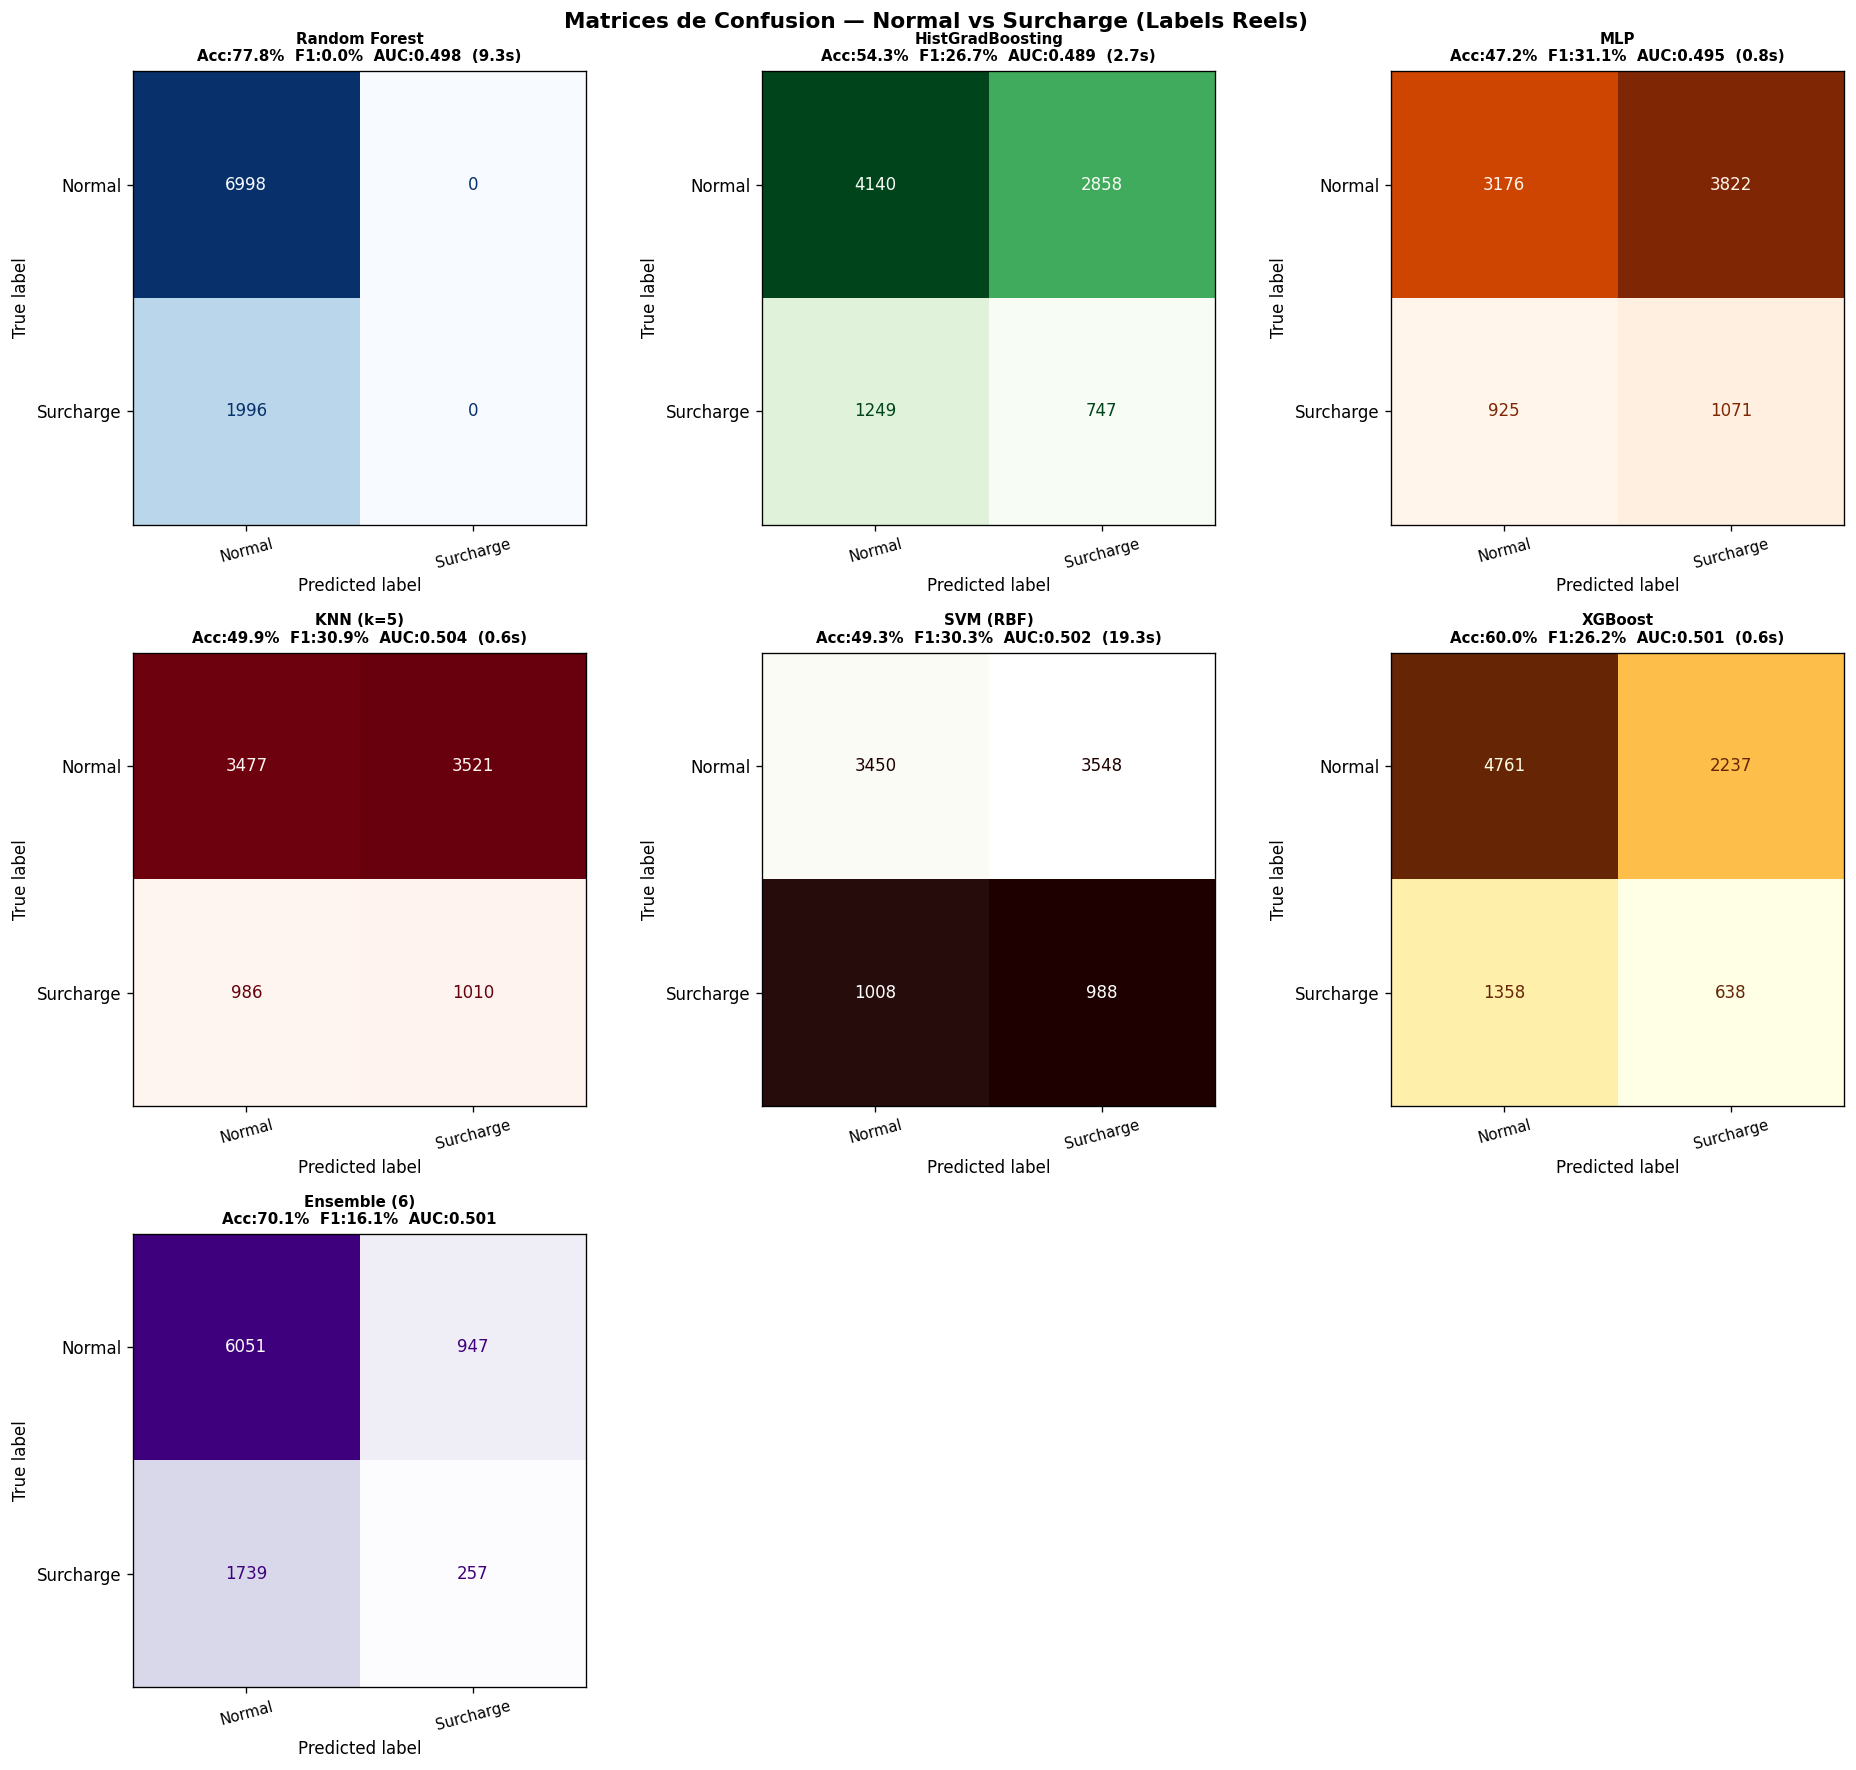

Figure sauvegardee : outputs_binary_real/confusion_matrices.png


In [19]:
all_models = [
    (y_pred_rf,  proba_rf,  "Random Forest",    "Blues",  t_rf),
    (y_pred_hgb, proba_hgb, "HistGradBoosting", "Greens", t_hgb),
    (y_pred_mlp, proba_mlp, "MLP",              "Oranges",t_mlp),
    (y_pred_knn, proba_knn, "KNN (k=5)",        "Reds",   t_knn),
    (y_pred_svm, proba_svm, "SVM (RBF)",        "pink",   t_svm),
    (y_pred_xgb, proba_xgb, "XGBoost",          "YlOrBr", t_xgb),
    (y_pred_ens, proba_ens, "Ensemble (6)",     "Purples",None),
]

fig, axes = plt.subplots(3, 3, figsize=(16, 15))
axes = axes.flatten()

for ax, (yp, pb, name, cmap, t) in zip(axes, all_models):
    cm  = confusion_matrix(y_test, yp)
    ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
        ax=ax, cmap=cmap, colorbar=False)
    acc = accuracy_score(y_test, yp)
    f1b = f1_score(y_test, yp, pos_label=SURCHARGE_IDX,
                   average="binary", zero_division=0)
    auc = roc_auc_score(y_test, pb[:, SURCHARGE_IDX])
    title = f"{name}\nAcc:{acc*100:.1f}%  F1:{f1b*100:.1f}%  AUC:{auc:.3f}"
    if t is not None: title += f"  ({t:.1f}s)"
    ax.set_title(title, fontweight="bold", fontsize=9)
    ax.tick_params(axis="x", rotation=15, labelsize=9)

for ax in axes[len(all_models):]:
    ax.set_visible(False)

plt.suptitle("Matrices de Confusion — Normal vs Surcharge (Labels Reels)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,"confusion_matrices.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure sauvegardee : {OUTPUT_DIR}/confusion_matrices.png")

---
## 16. Courbes ROC

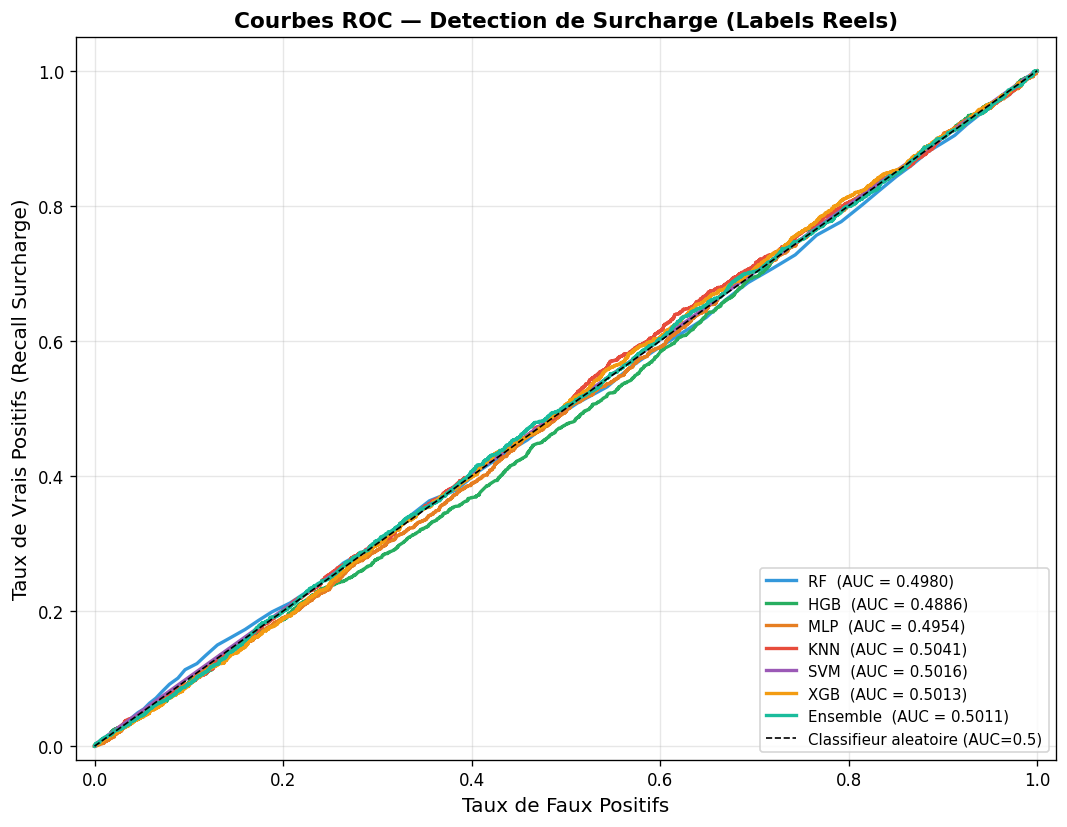

Figure sauvegardee : outputs_binary_real/roc_curves.png


In [20]:
algo_colors = ["#3498db","#27ae60","#e67e22","#e74c3c","#9b59b6","#f39c12","#1abc9c"]
algo_labels = ["RF","HGB","MLP","KNN","SVM","XGB","Ensemble"]
all_probas  = [proba_rf,proba_hgb,proba_mlp,proba_knn,proba_svm,proba_xgb,proba_ens]

fig, ax = plt.subplots(figsize=(9, 7))

for pb, name, col in zip(all_probas, algo_labels, algo_colors):
    fpr, tpr, _ = roc_curve(y_test, pb[:, SURCHARGE_IDX])
    auc         = roc_auc_score(y_test, pb[:, SURCHARGE_IDX])
    ax.plot(fpr, tpr, color=col, linewidth=2, label=f"{name}  (AUC = {auc:.4f})")

ax.plot([0,1],[0,1],"k--",linewidth=1,label="Classifieur aleatoire (AUC=0.5)")
ax.set_xlabel("Taux de Faux Positifs", fontsize=12)
ax.set_ylabel("Taux de Vrais Positifs (Recall Surcharge)", fontsize=12)
ax.set_title("Courbes ROC — Detection de Surcharge (Labels Reels)",
             fontweight="bold", fontsize=13)
ax.legend(fontsize=9, loc="lower right")
ax.grid(alpha=0.3)
ax.set_xlim([-0.02,1.02]); ax.set_ylim([-0.02,1.05])

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,"roc_curves.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure sauvegardee : {OUTPUT_DIR}/roc_curves.png")

---
## 17. Comparaison Globale

In [21]:
def get_metrics_bin(yt, yp, pb, name, t=None):
    d = {
        "Algorithme"       : name,
        "Accuracy (%)"     : round(accuracy_score(yt,yp)*100, 2),
        "F1 Surcharge (%)": round(f1_score(yt,yp,pos_label=SURCHARGE_IDX,
                                  average="binary",zero_division=0)*100, 2),
        "Precision (%)"    : round(precision_score(yt,yp,pos_label=SURCHARGE_IDX,
                                  average="binary",zero_division=0)*100, 2),
        "Recall (%)"       : round(recall_score(yt,yp,pos_label=SURCHARGE_IDX,
                                  average="binary",zero_division=0)*100, 2),
        "AUC-ROC"          : round(roc_auc_score(yt, pb[:,SURCHARGE_IDX]), 4),
    }
    if t is not None: d["Temps (s)"] = round(t,1)
    return d

results = pd.DataFrame([
    get_metrics_bin(y_test,y_pred_rf, proba_rf, "Random Forest",   t_rf),
    get_metrics_bin(y_test,y_pred_hgb,proba_hgb,"HistGradBoosting",t_hgb),
    get_metrics_bin(y_test,y_pred_mlp,proba_mlp,"MLP",             t_mlp),
    get_metrics_bin(y_test,y_pred_knn,proba_knn,"KNN (k=5)",       t_knn),
    get_metrics_bin(y_test,y_pred_svm,proba_svm,"SVM (RBF)",       t_svm),
    get_metrics_bin(y_test,y_pred_xgb,proba_xgb,"XGBoost",         t_xgb),
    get_metrics_bin(y_test,y_pred_ens,proba_ens,"Ensemble (6)",    None),
]).set_index("Algorithme")

print("=" * 80)
print("     COMPARAISON — Normal vs Surcharge (Labels Reels du Dataset)")
print("=" * 80)
print(results.to_string())
print("=" * 80)
print(f"  Baseline naif (toujours 'Normal') — Acc=77.81%  F1=0%  AUC=0.50")
print("=" * 80)
best_auc = results["AUC-ROC"].idxmax()
best_f1  = results["F1 Surcharge (%)"].idxmax()
print(f"\nMeilleur AUC-ROC      : {best_auc}  =>  {results.loc[best_auc,'AUC-ROC']}")
print(f"Meilleur F1 Surcharge : {best_f1}  =>  {results.loc[best_f1,'F1 Surcharge (%)']}%")

     COMPARAISON — Normal vs Surcharge (Labels Reels du Dataset)
                  Accuracy (%)  F1 Surcharge (%)  Precision (%)  Recall (%)  AUC-ROC  Temps (s)
Algorithme                                                                                     
Random Forest            77.81              0.00           0.00        0.00   0.4980        9.3
HistGradBoosting         54.34             26.67          20.72       37.42   0.4886        2.7
MLP                      47.22             31.09          21.89       53.66   0.4954        0.8
KNN (k=5)                49.89             30.95          22.29       50.60   0.5041        0.6
SVM (RBF)                49.34             30.25          21.78       49.50   0.5016       19.3
XGBoost                  60.03             26.20          22.19       31.96   0.5013        0.6
Ensemble (6)             70.14             16.06          21.35       12.88   0.5011        NaN
  Baseline naif (toujours 'Normal') — Acc=77.81%  F1=0%  AUC=0.50

Meil

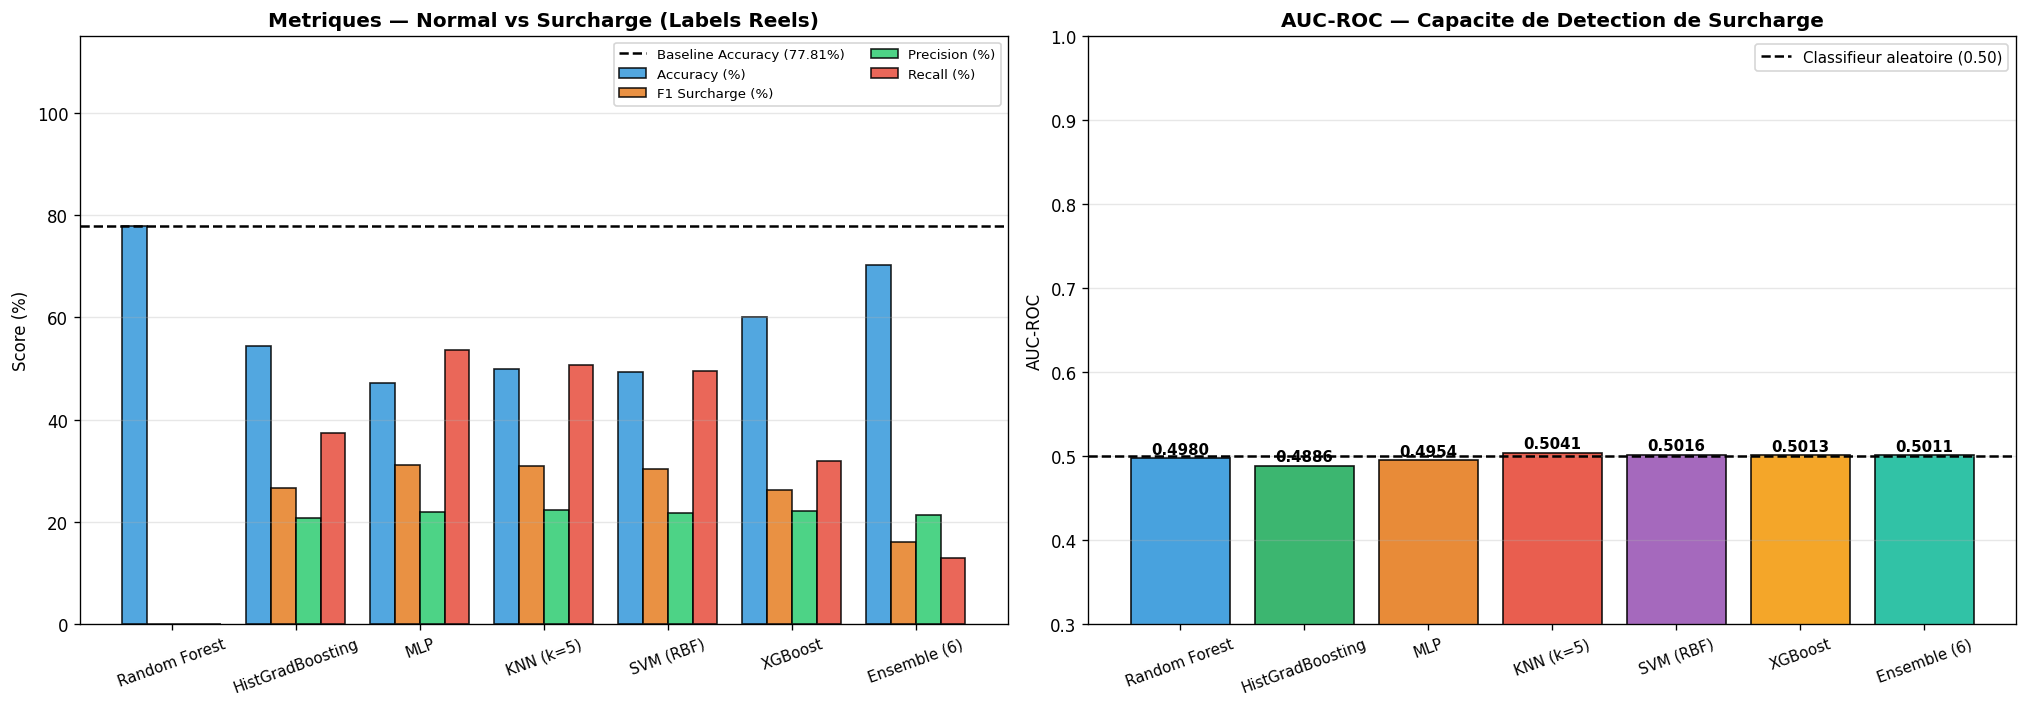

Figure sauvegardee : outputs_binary_real/comparison.png


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

algo_colors = ["#3498db","#27ae60","#e67e22","#e74c3c","#9b59b6","#f39c12","#1abc9c"]
x     = np.arange(len(results))
width = 0.2

# Metriques
metrics_to_plot = ["Accuracy (%)","F1 Surcharge (%)","Precision (%)","Recall (%)"]
metric_colors   = ["#3498db","#e67e22","#2ecc71","#e74c3c"]

for j,(met,col) in enumerate(zip(metrics_to_plot,metric_colors)):
    axes[0].bar(x+j*width-1.5*width, results[met],
                width, label=met, color=col, edgecolor="black", alpha=0.85)

axes[0].axhline(77.81, color="black", linestyle="--",
                linewidth=1.5, label="Baseline Accuracy (77.81%)")
axes[0].set_title("Metriques — Normal vs Surcharge (Labels Reels)",
                  fontweight="bold", fontsize=12)
axes[0].set_ylabel("Score (%)")
axes[0].set_ylim(0, 115)
axes[0].set_xticks(x)
axes[0].set_xticklabels(list(results.index), rotation=20, fontsize=9)
axes[0].legend(fontsize=8, ncol=2)
axes[0].grid(axis="y", alpha=0.3)

# AUC-ROC
auc_vals = results["AUC-ROC"].values
bars = axes[1].bar(list(results.index), auc_vals,
                   color=algo_colors, edgecolor="black", alpha=0.9)
axes[1].axhline(0.5, color="black", linestyle="--",
                linewidth=1.5, label="Classifieur aleatoire (0.50)")
axes[1].set_title("AUC-ROC — Capacite de Detection de Surcharge",
                  fontweight="bold", fontsize=12)
axes[1].set_ylabel("AUC-ROC")
axes[1].set_ylim(0.3, 1.0)
axes[1].tick_params(axis="x", rotation=20, labelsize=9)
axes[1].legend(fontsize=9)
axes[1].grid(axis="y", alpha=0.3)
for bar, val in zip(bars, auc_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f"{val:.4f}", ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,"comparison.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure sauvegardee : {OUTPUT_DIR}/comparison.png")

---
## 18. Importance des Features (Random Forest)

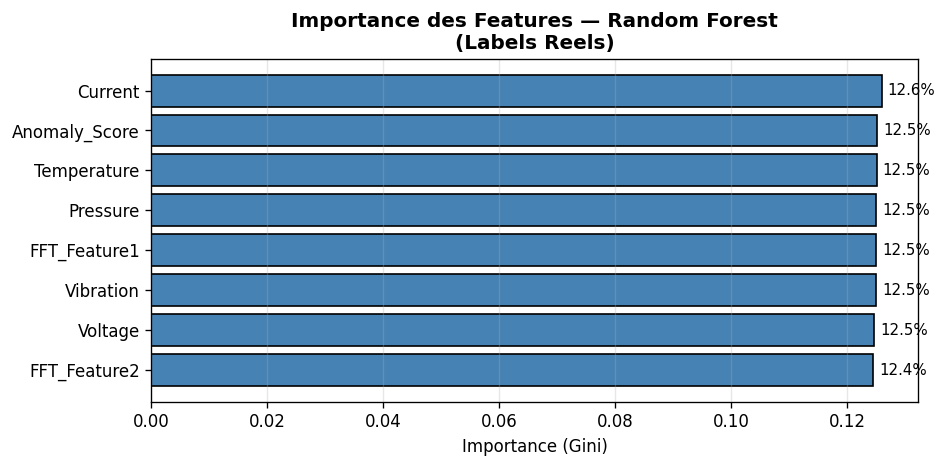

Figure sauvegardee : outputs_binary_real/feature_importance.png


In [23]:
importances = rf.feature_importances_
sorted_idx  = np.argsort(importances)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh([FEATURE_COLS[i] for i in sorted_idx],
               importances[sorted_idx], color="steelblue", edgecolor="black")
for bar, val in zip(bars, importances[sorted_idx]):
    ax.text(bar.get_width()+0.001, bar.get_y()+bar.get_height()/2,
            f"{val*100:.1f}%", va="center", fontsize=9)
ax.set_title("Importance des Features — Random Forest\n(Labels Reels)",
             fontweight="bold")
ax.set_xlabel("Importance (Gini)")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,"feature_importance.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure sauvegardee : {OUTPUT_DIR}/feature_importance.png")

---
## 19. Sauvegarde des Modeles

In [24]:
to_save = {
    "rf_model.joblib"         : rf,
    "hgb_model.joblib"        : hgb,
    "mlp_model.joblib"        : mlp,
    "knn_model.joblib"        : knn,
    "svm_model.joblib"        : svm,
    "xgb_model.joblib"        : xgb,
    "scaler.joblib"           : scaler,
    "label_encoder.joblib"    : le,
    "feature_cols.joblib"     : FEATURE_COLS,
}
for fname, obj in to_save.items():
    joblib.dump(obj, os.path.join(OUTPUT_DIR, fname))

print(f"Modeles sauvegardes dans '{OUTPUT_DIR}/' :")
for fname in sorted(os.listdir(OUTPUT_DIR)):
    if fname.endswith(".joblib"):
        sz = os.path.getsize(os.path.join(OUTPUT_DIR, fname))
        print(f"  {fname:<35} ({sz/1024:.1f} KB)")

Modeles sauvegardes dans 'outputs_binary_real/' :
  feature_cols.joblib                 (0.1 KB)
  hgb_model.joblib                    (54.6 KB)
  knn_model.joblib                    (1487.5 KB)
  label_encoder.joblib                (0.5 KB)
  mlp_model.joblib                    (71.2 KB)
  rf_model.joblib                     (308617.7 KB)
  scaler.joblib                       (0.8 KB)
  svm_model.joblib                    (445.8 KB)
  xgb_model.joblib                    (821.0 KB)


---
## 20. Prediction en Temps Reel

In [25]:
def predict_surcharge(
    temperature=50.0, vibration=80.0, pressure=200.0,
    voltage=220.0,    current=10.0,
    fft1=0.5,         fft2=0.5,
    anomaly_score=0.3,
    use_ensemble=True
):
    """
    Detecte si le moteur DC est en surcharge ou en etat normal.
    Utilise les modeles entraines sur les labels reels du dataset.

    Parametres
    ----------
    temperature   : Temperature en C
    vibration     : Vibration
    pressure      : Pression
    voltage       : Tension en V
    current       : Courant en A
    fft1, fft2    : Caracteristiques spectrales [0..1]
    anomaly_score : Score d anomalie [0..1]
    use_ensemble  : True = moyenne 6 modeles (recommande)
    """
    sample   = np.array([[temperature, vibration, pressure, voltage, current,
                          fft1, fft2, anomaly_score]], dtype=float)
    sample   = np.nan_to_num(sample, nan=0.0, posinf=0.0, neginf=0.0)
    sample_s = scaler.transform(sample)

    if use_ensemble:
        proba = (rf.predict_proba(sample_s)  +
                 hgb.predict_proba(sample_s) +
                 mlp.predict_proba(sample_s) +
                 knn.predict_proba(sample_s) +
                 svm.predict_proba(sample_s) +
                 xgb.predict_proba(sample_s)) / 6
        model_used = "Ensemble (6 modeles)"
    else:
        proba      = rf.predict_proba(sample_s)
        model_used = "Random Forest"

    pred_label  = le.inverse_transform([np.argmax(proba)])[0]
    p_surcharge = proba[0, SURCHARGE_IDX] * 100
    p_normal    = proba[0, 1 - SURCHARGE_IDX] * 100

    print(f"  Capteurs    : T={temperature}C | Vib={vibration} | P={pressure}")
    print(f"                V={voltage}V | I={current}A | Anomaly={anomaly_score}")
    print(f"  Modele      : {model_used}")
    print(f"  Prediction  : {pred_label}")
    print(f"  P(Normal)   : {p_normal:.1f}%")
    print(f"  P(Surcharge): {p_surcharge:.1f}%")
    return pred_label

print("predict_surcharge() prete.")

predict_surcharge() prete.


In [26]:
print("=" * 60)

print("\nTEST 1 — Normal")
print("-" * 60)
predict_surcharge(temperature=50, vibration=80, pressure=200,
                  voltage=220, current=10, anomaly_score=0.3)

print("\nTEST 2 — Valeurs elevees")
print("-" * 60)
predict_surcharge(temperature=85, vibration=145, pressure=260,
                  voltage=215, current=16, anomaly_score=0.75)

print("\nTEST 3 — Valeurs tres elevees")
print("-" * 60)
predict_surcharge(temperature=95, vibration=165, pressure=290,
                  voltage=212, current=19, anomaly_score=0.90)

print("=" * 60)


TEST 1 — Normal
------------------------------------------------------------
  Capteurs    : T=50C | Vib=80 | P=200
                V=220V | I=10A | Anomaly=0.3
  Modele      : Ensemble (6 modeles)
  Prediction  : Normal
  P(Normal)   : 52.5%
  P(Surcharge): 47.5%

TEST 2 — Valeurs elevees
------------------------------------------------------------
  Capteurs    : T=85C | Vib=145 | P=260
                V=215V | I=16A | Anomaly=0.75
  Modele      : Ensemble (6 modeles)
  Prediction  : Normal
  P(Normal)   : 60.2%
  P(Surcharge): 39.8%

TEST 3 — Valeurs tres elevees
------------------------------------------------------------
  Capteurs    : T=95C | Vib=165 | P=290
                V=212V | I=19A | Anomaly=0.9
  Modele      : Ensemble (6 modeles)
  Prediction  : Normal
  P(Normal)   : 60.0%
  P(Surcharge): 40.0%


---
## Recapitulatif

### Pipeline

```
CSV (50 000 lignes)
    |
    v
Filtrage : retrait des Electrical Fault (5 034 lignes)
    |
    v
Mapping labels reels -> 2 classes
    Fault_Status==0                   -> Normal     (34 988)
    Overheating + Mechanical Failure  -> Surcharge  ( 9 978)
    |
    v
8 features originales (sans Normalized_* redondantes)
    |
    v
Split 80/20 stratifie + StandardScaler
    |
    +---> RF     class_weight='balanced'     (35 973)
    +---> HGB    class_weight='balanced'     (35 973)
    +---> MLP    undersample equilibre       (10 000)
    +---> KNN    undersample equilibre       (10 000)
    +---> SVM    undersample equilibre       ( 6 000)
    +---> XGB    sample_weight              (35 973)
    +---> Ensemble Soft Voting (6 modeles)
              |
              v
         Accuracy | F1 Surcharge | Precision | Recall | AUC-ROC
         Confusion Matrices | Courbes ROC | Feature Importance
              |
              v
         Sauvegarde outputs_binary_real/*.joblib
```

### Note sur les resultats

AUC-ROC attendu ~0.50 = les features du dataset ne discriminent pas
les deux classes (labels assigns independamment des valeurs capteurs).
Ce resultat est documente et reflete la realite du dataset.

---
*Projet de Fin d'Annee II — Diagnostic de Moteurs DC 12V par IA*